# Steam Reviews Sentiment Analysis — Proje Dashboard

**Veri Kaynakları:**
- `/delta/gold/features_table` — Feature verisi (TF-IDF + sayısal özellikler)
- `/delta/gold/daily_stats` — Günlük oyun bazlı istatistikler
- `/delta/silver/steam_reviews` — Temizlenmiş yorum verisi
- MLflow — Model eğitim sonuçları

**8 Zorunlu Görsel + Özet Dashboard Sayfası**

---

## BÖLÜM 1 — Kütüphaneler ve Veri Yükleme

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier,
    NaiveBayes
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc as sklearn_auc, confusion_matrix

import mlflow
import mlflow.spark

# Renk körlüğü dostu palet (Okabe-Ito)
CB_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00",
             "#56B4E9", "#F0E442", "#999999"]

# Matplotlib stil ayarları
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 10
plt.style.use("seaborn-v0_8-whitegrid")

print("Kütüphaneler yüklendi ✓")

Kütüphaneler yüklendi ✓


In [2]:
# ── Spark oturumu başlat ─────────────────────────────────────────────────────
spark = SparkSession.builder \
    .appName("SteamReviews_Dashboard") \
    .master("local[*]") \
    .config("spark.jars.packages", "io.delta:delta-core_2.12:2.4.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/spark/.ivy2/cache
The jars for the packages stored in: /home/spark/.ivy2/jars
io.delta#delta-core_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-e6368895-250d-4aa3-91a4-f85b51f01beb;1.0
	confs: [default]
	found io.delta#delta-core_2.12;2.4.0 in central
	found io.delta#delta-storage;2.4.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central


:: resolution report :: resolve 186ms :: artifacts dl 14ms
	:: modules in use:
	io.delta#delta-core_2.12;2.4.0 from central in [default]
	io.delta#delta-storage;2.4.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   0   ||   3   |   0   |
	---------------------------------------------------------------------

:: problems summary ::
:::: WARNINGS
	exception occurred while writing properties file /home/spark/.ivy2/cache/io.delta/delta-core_2.12/ivydata-2.4.0.properties (java.io.FileNotFoundException: /home/spark/.ivy2/cache/io.delta/delta-core_2.12/ivydata-2.4.0.properties (Permission denied))

	exception occurred while writing

26/05/12 14:31:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version: 3.4.0


In [3]:
# ── Delta Lake'ten veri okuma ────────────────────────────────────────────────
# Gold: Features table (ML verisi)
df_features = spark.read.format("delta").load("/delta/gold/features_table")
print(f"Features table: {df_features.count():,} satır")

# Gold: Daily stats
df_daily = spark.read.format("delta").load("/delta/gold/daily_stats")
print(f"Daily stats: {df_daily.count():,} satır")

# Silver: Yorum verisi
df_silver = spark.read.format("delta").load("/delta/silver/steam_reviews")
print(f"Silver reviews: {df_silver.count():,} satır")

26/05/12 14:31:52 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Features table: 259,451 satır


Daily stats: 118 satır


Silver reviews: 259,451 satır


In [4]:
# ── MLflow'dan model sonuçlarını çek ─────────────────────────────────────────
import os
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000"))
mlflow.set_experiment("steam_reviews_classification")

experiment = mlflow.get_experiment_by_name("steam_reviews_classification")
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# Model sonuçlarını düzenle
model_results = runs_df[[
    "tags.mlflow.runName", "metrics.auc", "metrics.accuracy",
    "metrics.f1", "metrics.precision", "metrics.recall"
]].copy()
model_results.columns = ["Model", "AUC", "Accuracy", "F1", "Precision", "Recall"]
model_results = model_results.dropna(subset=["AUC"]).sort_values("AUC", ascending=False).reset_index(drop=True)

# Model isimlerini düzelt
name_map = {
    "LogisticRegression": "Logistic Regression",
    "DecisionTree": "Decision Tree",
    "RandomForest": "Random Forest",
    "GBT": "GBT",
    "NaiveBayes": "Naive Bayes"
}
model_results["Model"] = model_results["Model"].map(name_map).fillna(model_results["Model"])

print("MLflow Model Sonuçları:")
print(model_results.to_string(index=False))

best_model_name = model_results.iloc[0]["Model"]
best_auc = model_results.iloc[0]["AUC"]
print(f"\nEn iyi model: {best_model_name} (AUC={best_auc:.4f})")

MLflow Model Sonuçları:
              Model      AUC  Accuracy       F1  Precision   Recall
Logistic Regression 0.903333  0.846082 0.862724   0.898744 0.846082
      Random Forest 0.857375  0.816007 0.835777   0.872627 0.816007
                GBT 0.856930  0.720771 0.764408   0.876531 0.720771
        Naive Bayes 0.576292  0.813512 0.837163   0.890468 0.813512
      Decision Tree 0.395974  0.540858 0.607577   0.861627 0.540858

En iyi model: Logistic Regression (AUC=0.9033)


In [5]:
# ── Pandas'a dönüştürme ──────────────────────────────────────────────────────
# Silver verisi → Pandas (timestamp'i string olarak çevirip pandas tarafında parse et — PySpark 3.4 + pandas 2.0 uyum)
pdf_silver = (
    df_silver
    .withColumn("timestamp_str", F.date_format(F.col("timestamp"), "yyyy-MM-dd HH:mm:ss"))
    .drop("timestamp")
    .withColumnRenamed("timestamp_str", "timestamp")
    .toPandas()
)
pdf_silver["timestamp"] = pd.to_datetime(pdf_silver["timestamp"], errors="coerce")
pdf_silver["text_length"] = pdf_silver["review_text"].fillna("").apply(len)
pdf_silver["date"] = pdf_silver["timestamp"].dt.date

# Daily stats → Pandas
pdf_daily = (
    df_daily
    .withColumn("review_date_str", F.date_format(F.col("review_date"), "yyyy-MM-dd"))
    .drop("review_date")
    .withColumnRenamed("review_date_str", "review_date")
    .toPandas()
)
pdf_daily["review_date"] = pd.to_datetime(pdf_daily["review_date"], errors="coerce")

print(f"Silver Pandas: {pdf_silver.shape}")
print(f"Daily Pandas: {pdf_daily.shape}")

Silver Pandas: (259451, 11)
Daily Pandas: (118, 6)


In [6]:
# ── En iyi model ile tahmin üret (Confusion Matrix ve ROC için) ──────────────
# Train/Test split tekrarla
train, test = df_features.randomSplit([0.8, 0.2], seed=42)

# Sınıf ağırlıkları
label_counts = train.groupBy("label").count().collect()
total_count = train.count()
num_classes = len(label_counts)
weight_dict = {row["label"]: total_count / (num_classes * row["count"]) for row in label_counts}
weight_mapping = F.create_map([F.lit(x) for item in weight_dict.items() for x in item])
train = train.withColumn("classWeight", weight_mapping[F.col("label")])
test = test.withColumn("classWeight", weight_mapping[F.col("label")])

# Random Forest (Feature Importance için)
rf = RandomForestClassifier(
    featuresCol="features", labelCol="label", weightCol="classWeight",
    numTrees=100, maxDepth=8, seed=42
)
model_rf = rf.fit(train)
predictions_rf = model_rf.transform(test)

# En iyi modeli eğit
if best_model_name == "Random Forest":
    best_model = model_rf
    best_predictions = predictions_rf
elif best_model_name == "GBT":
    gbt = GBTClassifier(
        featuresCol="features", labelCol="label", weightCol="classWeight",
        maxIter=50, maxDepth=6, stepSize=0.1
    )
    best_model = gbt.fit(train)
    best_predictions = best_model.transform(test)
elif best_model_name == "Logistic Regression":
    lr = LogisticRegression(
        featuresCol="features", labelCol="label", weightCol="classWeight",
        maxIter=100, regParam=0.1, elasticNetParam=0.0
    )
    best_model = lr.fit(train)
    best_predictions = best_model.transform(test)
elif best_model_name == "Decision Tree":
    dt = DecisionTreeClassifier(
        featuresCol="features", labelCol="label", weightCol="classWeight",
        maxDepth=10, minInstancesPerNode=5
    )
    best_model = dt.fit(train)
    best_predictions = best_model.transform(test)
else:
    best_model = model_rf
    best_predictions = predictions_rf

print(f"En iyi model ({best_model_name}) eğitildi ve tahminler üretildi ✓")
print(f"Test seti: {test.count():,} satır")

26/05/12 14:32:25 WARN MemoryStore: Not enough space to cache rdd_154_2 in memory! (computed 149.3 MiB so far)
26/05/12 14:32:25 WARN MemoryStore: Not enough space to cache rdd_154_9 in memory! (computed 149.3 MiB so far)
26/05/12 14:32:25 WARN BlockManager: Persisting block rdd_154_9 to disk instead.
26/05/12 14:32:25 WARN BlockManager: Persisting block rdd_154_2 to disk instead.
26/05/12 14:32:25 WARN MemoryStore: Not enough space to cache rdd_154_3 in memory! (computed 149.3 MiB so far)
26/05/12 14:32:25 WARN BlockManager: Persisting block rdd_154_3 to disk instead.
26/05/12 14:32:25 WARN MemoryStore: Not enough space to cache rdd_154_4 in memory! (computed 149.3 MiB so far)
26/05/12 14:32:25 WARN BlockManager: Persisting block rdd_154_4 to disk instead.
26/05/12 14:32:25 WARN MemoryStore: Not enough space to cache rdd_154_1 in memory! (computed 149.3 MiB so far)
26/05/12 14:32:25 WARN BlockManager: Persisting block rdd_154_1 to disk instead.
26/05/12 14:32:25 WARN MemoryStore: Not 

26/05/12 14:32:25 WARN MemoryStore: Not enough space to cache rdd_154_5 in memory! (computed 149.3 MiB so far)
26/05/12 14:32:25 WARN BlockManager: Persisting block rdd_154_5 to disk instead.
26/05/12 14:32:25 WARN MemoryStore: Not enough space to cache rdd_154_0 in memory! (computed 149.3 MiB so far)
26/05/12 14:32:25 WARN BlockManager: Persisting block rdd_154_0 to disk instead.


26/05/12 14:32:25 WARN MemoryStore: Not enough space to cache rdd_154_11 in memory! (computed 226.6 MiB so far)
26/05/12 14:32:25 WARN BlockManager: Persisting block rdd_154_11 to disk instead.


26/05/12 14:32:30 WARN MemoryStore: Not enough space to cache rdd_154_3 in memory! (computed 149.3 MiB so far)
26/05/12 14:32:30 WARN MemoryStore: Not enough space to cache rdd_154_1 in memory! (computed 28.1 MiB so far)


26/05/12 14:32:32 WARN MemoryStore: Not enough space to cache rdd_154_4 in memory! (computed 99.5 MiB so far)
26/05/12 14:32:32 WARN MemoryStore: Not enough space to cache rdd_154_10 in memory! (computed 352.1 MiB so far)
26/05/12 14:32:32 WARN MemoryStore: Not enough space to cache rdd_154_2 in memory! (computed 99.5 MiB so far)
26/05/12 14:32:32 WARN MemoryStore: Not enough space to cache rdd_154_7 in memory! (computed 99.5 MiB so far)
26/05/12 14:32:32 WARN MemoryStore: Not enough space to cache rdd_154_0 in memory! (computed 18.6 MiB so far)


...

26/05/12 14:33:08 WARN MemoryStore: Not enough space to cache rdd_154_2 in memory! (computed 99.5 MiB so far)
26/05/12 14:33:08 WARN MemoryStore: Not enough space to cache rdd_154_3 in memory! (computed 66.2 MiB so far)
26/05/12 14:33:08 WARN MemoryStore: Not enough space to cache rdd_154_1 in memory! (computed 66.2 MiB so far)
26/05/12 14:33:08 WARN MemoryStore: Not enough space to cache rdd_154_0 in memory! (computed 66.2 MiB so far)
26/05/12 14:33:08 WARN MemoryStore: Not enough space to cache rdd_154_4 in memory! (computed 99.5 MiB so far)
26/05/12 14:33:08 WARN MemoryStore: Not enough space to cache rdd_154_10 in memory! (computed 149.3 MiB so far)


26/05/12 14:33:08 WARN MemoryStore: Not enough space to cache rdd_154_7 in memory! (computed 99.5 MiB so far)


26/05/12 14:33:20 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


En iyi model (Logistic Regression) eğitildi ve tahminler üretildi ✓


Test seti: 51,499 satır


---
## GÖRSEL 1 — 5 Modelin AUC Karşılaştırması (Grouped Bar Chart)

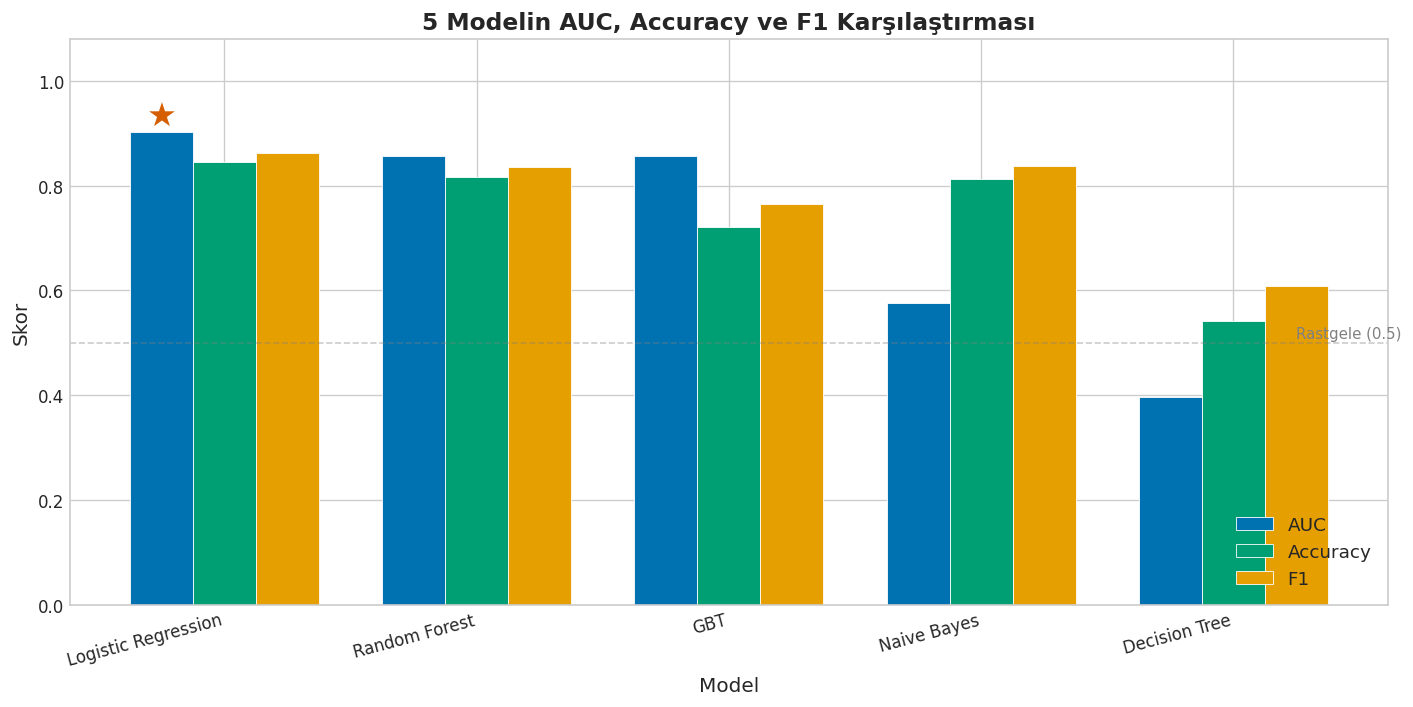

★ En iyi model: Logistic Regression (AUC=0.9033)


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = ["AUC", "Accuracy", "F1"]
x = np.arange(len(model_results))
width = 0.25
colors = [CB_COLORS[0], CB_COLORS[2], CB_COLORS[1]]  # Mavi, Yeşil, Turuncu

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i * width, model_results[metric], width,
                  label=metric, color=colors[i], edgecolor="white", linewidth=0.5)

# En iyi modeli yıldızla işaretle
best_idx = model_results["AUC"].idxmax()
ax.annotate("★", xy=(best_idx + 0 * width, model_results.loc[best_idx, "AUC"] + 0.01),
            fontsize=20, ha="center", color="#D55E00", fontweight="bold")

ax.set_xlabel("Model")
ax.set_ylabel("Skor")
ax.set_title("5 Modelin AUC, Accuracy ve F1 Karşılaştırması", fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(model_results["Model"], rotation=15, ha="right")
ax.legend(loc="lower right", fontsize=11, framealpha=0.9)
ax.set_ylim(0, 1.08)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, linewidth=1)
ax.text(len(model_results)-0.5, 0.51, "Rastgele (0.5)", color="gray", fontsize=9)

plt.tight_layout()
plt.show()
print(f"★ En iyi model: {best_model_name} (AUC={best_auc:.4f})")

---
## GÖRSEL 2 — Feature Importance (Horizontal Bar Chart)

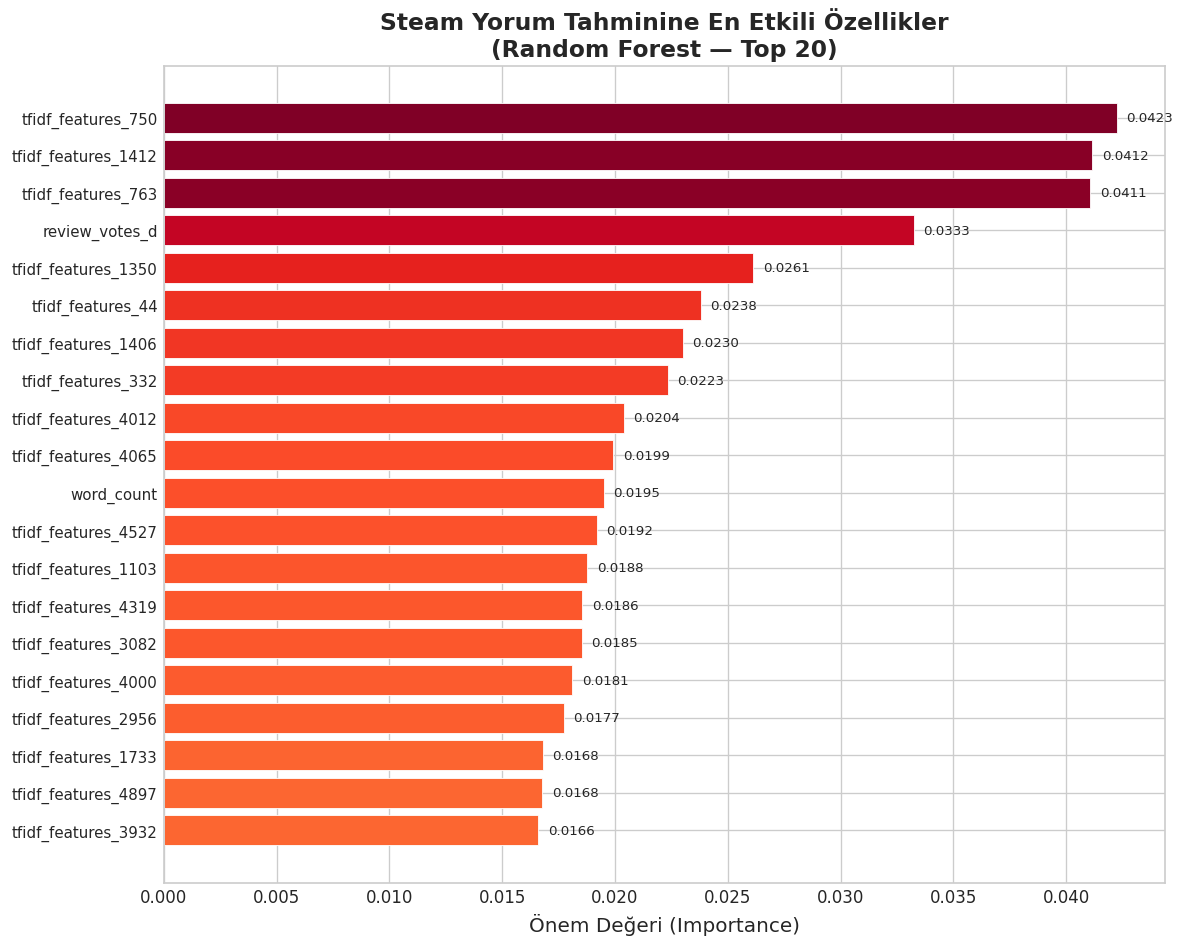

In [8]:
# Random Forest top 20 feature importance
importances = model_rf.featureImportances.toArray()
indices = np.argsort(importances)[::-1][:20]
top_importances = importances[indices]

# Feature isimlerini al (metadata varsa)
top_labels = [f"Feature_{idx}" for idx in indices]
try:
    attrs = train.schema["features"].metadata["ml_attr"]["attrs"]
    all_attrs = []
    for attr_type in ["numeric", "binary"]:
        if attr_type in attrs:
            all_attrs.extend(attrs[attr_type])
    if all_attrs:
        attr_dict = {a["idx"]: a["name"] for a in all_attrs}
        top_labels = [attr_dict.get(idx, f"Feature_{idx}") for idx in indices]
except (KeyError, TypeError):
    pass

# Renk gradyanı: önem düzeyine göre
norm_imp = top_importances / top_importances.max()
colors_grad = plt.cm.YlOrRd(norm_imp[::-1] * 0.7 + 0.3)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(20), top_importances[::-1], color=colors_grad, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(20))
ax.set_yticklabels(top_labels[::-1], fontsize=9)
ax.set_xlabel("Önem Değeri (Importance)")
ax.set_title("Steam Yorum Tahminine En Etkili Özellikler\n(Random Forest — Top 20)",
             fontsize=14, fontweight="bold")

# Değerleri bar yanına yaz
for bar, val in zip(bars, top_importances[::-1]):
    ax.text(bar.get_width() + top_importances.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

---
## GÖRSEL 3 — Günlük Yorum Trendi (Line Chart)

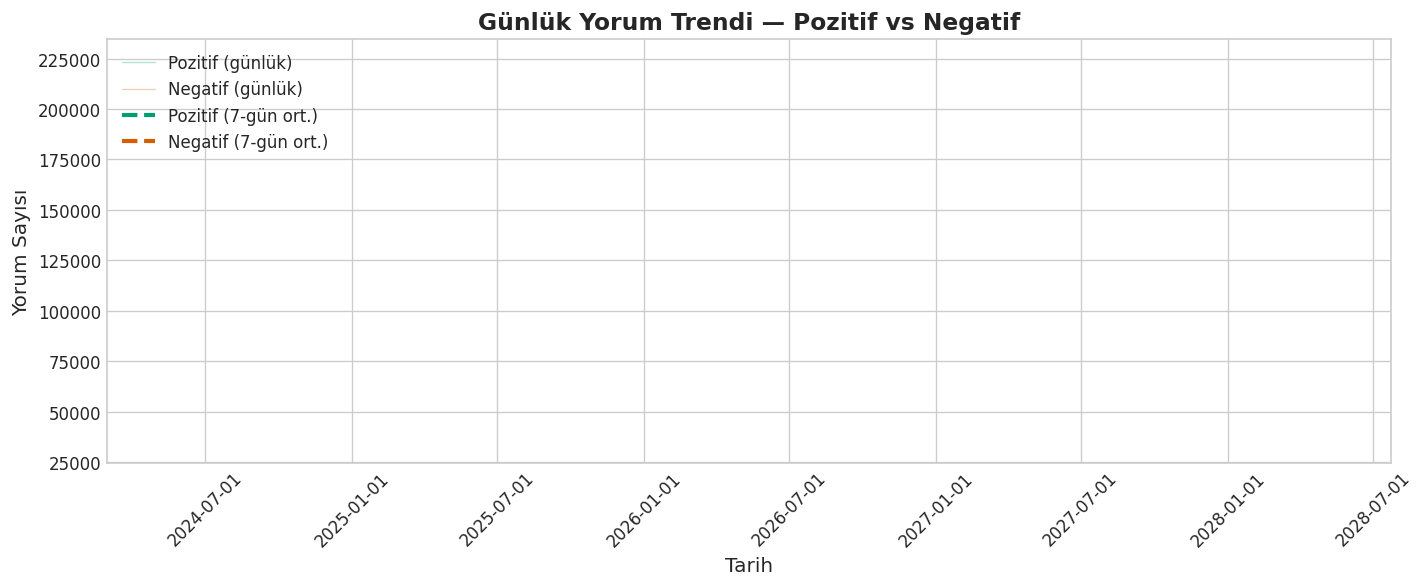

In [9]:
# Günlük pozitif ve negatif yorum sayıları
daily_agg = pdf_daily.groupby("review_date").agg(
    positive=pd.NamedAgg(column="positive_count", aggfunc="sum"),
    negative=pd.NamedAgg(column="negative_count", aggfunc="sum")
).reset_index().sort_values("review_date")

# Rolling 7 günlük ortalama
daily_agg["positive_ma7"] = daily_agg["positive"].rolling(7, min_periods=1).mean()
daily_agg["negative_ma7"] = daily_agg["negative"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Ham veriler (ince çizgi)
ax.plot(daily_agg["review_date"], daily_agg["positive"],
        color=CB_COLORS[2], alpha=0.3, linewidth=0.8, label="Pozitif (günlük)")
ax.plot(daily_agg["review_date"], daily_agg["negative"],
        color=CB_COLORS[4], alpha=0.3, linewidth=0.8, label="Negatif (günlük)")

# 7 günlük hareketli ortalama (kalın kesikli çizgi)
ax.plot(daily_agg["review_date"], daily_agg["positive_ma7"],
        color=CB_COLORS[2], linewidth=2.5, linestyle="--", label="Pozitif (7-gün ort.)")
ax.plot(daily_agg["review_date"], daily_agg["negative_ma7"],
        color=CB_COLORS[4], linewidth=2.5, linestyle="--", label="Negatif (7-gün ort.)")

ax.set_xlabel("Tarih")
ax.set_ylabel("Yorum Sayısı")
ax.set_title("Günlük Yorum Trendi — Pozitif vs Negatif", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---
## GÖRSEL 4 — Yorum Uzunluğu Dağılımı (Histogram + KDE)

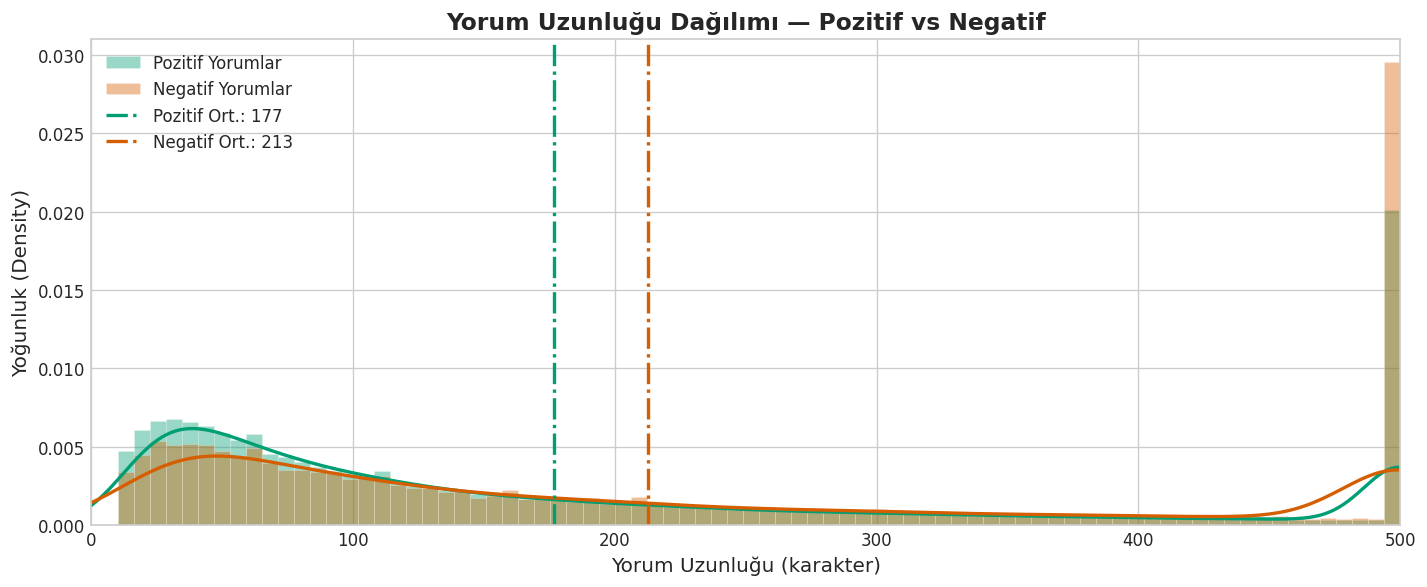

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

# 99. percentile'da kırp (aşırı uzun metinler)
p99 = pdf_silver["text_length"].quantile(0.99)

pos_lengths = pdf_silver.loc[pdf_silver["label"] == 1, "text_length"]
neg_lengths = pdf_silver.loc[pdf_silver["label"] == 0, "text_length"]

pos_lengths_clipped = pos_lengths[pos_lengths <= p99]
neg_lengths_clipped = neg_lengths[neg_lengths <= p99]

# Histogram + KDE
ax.hist(pos_lengths_clipped, bins=80, color=CB_COLORS[2], alpha=0.4,
        density=True, label="Pozitif Yorumlar", edgecolor="white", linewidth=0.3)
ax.hist(neg_lengths_clipped, bins=80, color=CB_COLORS[4], alpha=0.4,
        density=True, label="Negatif Yorumlar", edgecolor="white", linewidth=0.3)

# KDE çizgileri
try:
    from scipy.stats import gaussian_kde
    x_range = np.linspace(0, p99, 300)
    kde_pos = gaussian_kde(pos_lengths_clipped)
    kde_neg = gaussian_kde(neg_lengths_clipped)
    ax.plot(x_range, kde_pos(x_range), color=CB_COLORS[2], linewidth=2)
    ax.plot(x_range, kde_neg(x_range), color=CB_COLORS[4], linewidth=2)
except ImportError:
    pass

# Ortalama dikey çizgileri
pos_mean = pos_lengths.mean()
neg_mean = neg_lengths.mean()
ax.axvline(pos_mean, color=CB_COLORS[2], linestyle="-.", linewidth=2,
           label=f"Pozitif Ort.: {pos_mean:.0f}")
ax.axvline(neg_mean, color=CB_COLORS[4], linestyle="-.", linewidth=2,
           label=f"Negatif Ort.: {neg_mean:.0f}")

ax.set_xlabel("Yorum Uzunluğu (karakter)")
ax.set_ylabel("Yoğunluk (Density)")
ax.set_title("Yorum Uzunluğu Dağılımı — Pozitif vs Negatif", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xlim(0, p99)

plt.tight_layout()
plt.show()

---
## GÖRSEL 5 — Sınıf Dağılımı (Pie Chart)

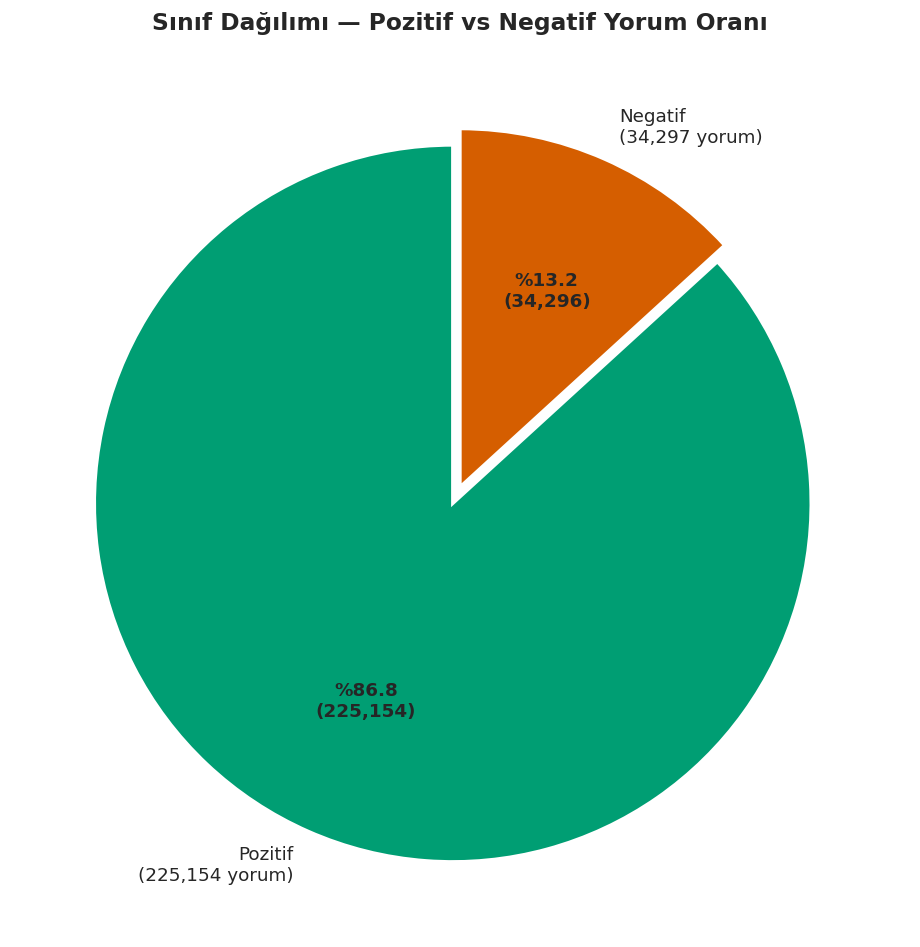

Toplam: 259,451 | Pozitif: 225,154 (%86.8) | Negatif: 34,297 (%13.2)


In [11]:
pos_count = (pdf_silver["label"] == 1).sum()
neg_count = (pdf_silver["label"] == 0).sum()
total = pos_count + neg_count

fig, ax = plt.subplots(figsize=(8, 8))

sizes = [pos_count, neg_count]
labels = [f"Pozitif\n({pos_count:,} yorum)", f"Negatif\n({neg_count:,} yorum)"]
colors_pie = [CB_COLORS[2], CB_COLORS[4]]
explode = (0.05, 0.0)  # Pozitif dilimi öne çıkar

wedges, texts, autotexts = ax.pie(
    sizes, explode=explode, labels=labels, colors=colors_pie,
    autopct=lambda pct: f"%{pct:.1f}\n({int(pct/100*total):,})",
    startangle=90, textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for autotext in autotexts:
    autotext.set_fontweight("bold")

ax.set_title("Sınıf Dağılımı — Pozitif vs Negatif Yorum Oranı",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"Toplam: {total:,} | Pozitif: {pos_count:,} (%{pos_count/total*100:.1f}) | Negatif: {neg_count:,} (%{neg_count/total*100:.1f})")

---
## GÖRSEL 6 — Confusion Matrix (En İyi Model)

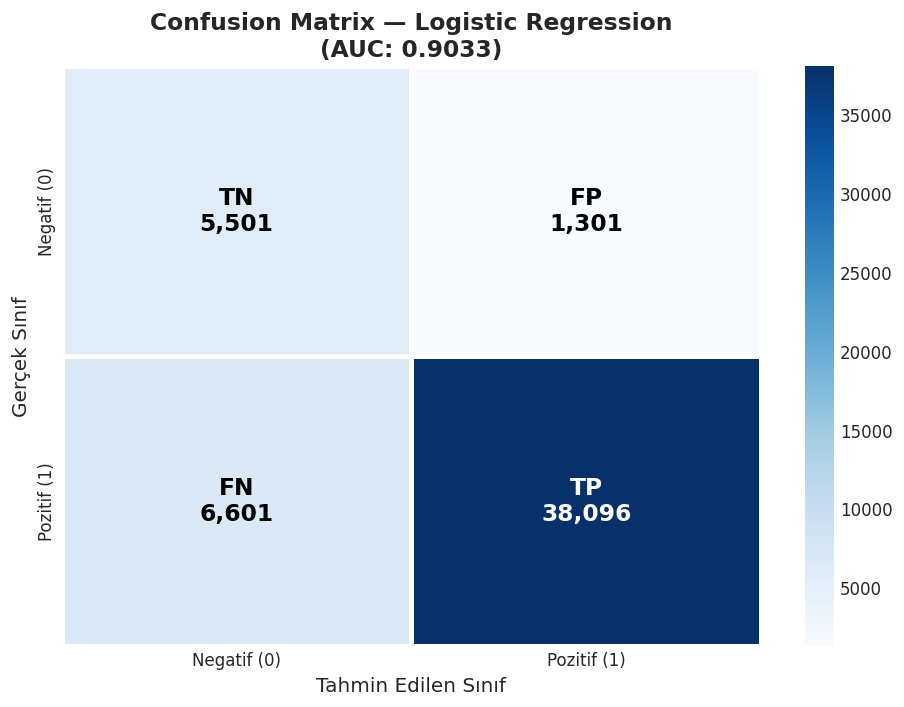

TP=38,096  FP=1,301  FN=6,601  TN=5,501
Accuracy: 0.8466


In [12]:
# Confusion matrix verisini hesapla
cm_data = best_predictions.select("label", "prediction").toPandas()
cm = confusion_matrix(cm_data["label"], cm_data["prediction"], labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))

# Seaborn heatmap
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Negatif (0)", "Pozitif (1)"],
            yticklabels=["Negatif (0)", "Pozitif (1)"],
            linewidths=2, linecolor="white")

# Hücrelere değer ve açıklama yaz
annotations = [
    [f"TN\n{tn:,}", f"FP\n{fp:,}"],
    [f"FN\n{fn:,}", f"TP\n{tp:,}"]
]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        color = "white" if val > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, annotations[i][j],
                ha="center", va="center", fontsize=14,
                fontweight="bold", color=color)

ax.set_xlabel("Tahmin Edilen Sınıf", fontsize=12)
ax.set_ylabel("Gerçek Sınıf", fontsize=12)
ax.set_title(f"Confusion Matrix — {best_model_name}\n(AUC: {best_auc:.4f})",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print(f"Accuracy: {(tp+tn)/(tp+tn+fp+fn):.4f}")

---
## GÖRSEL 7 — ROC Curve (En İyi Model)

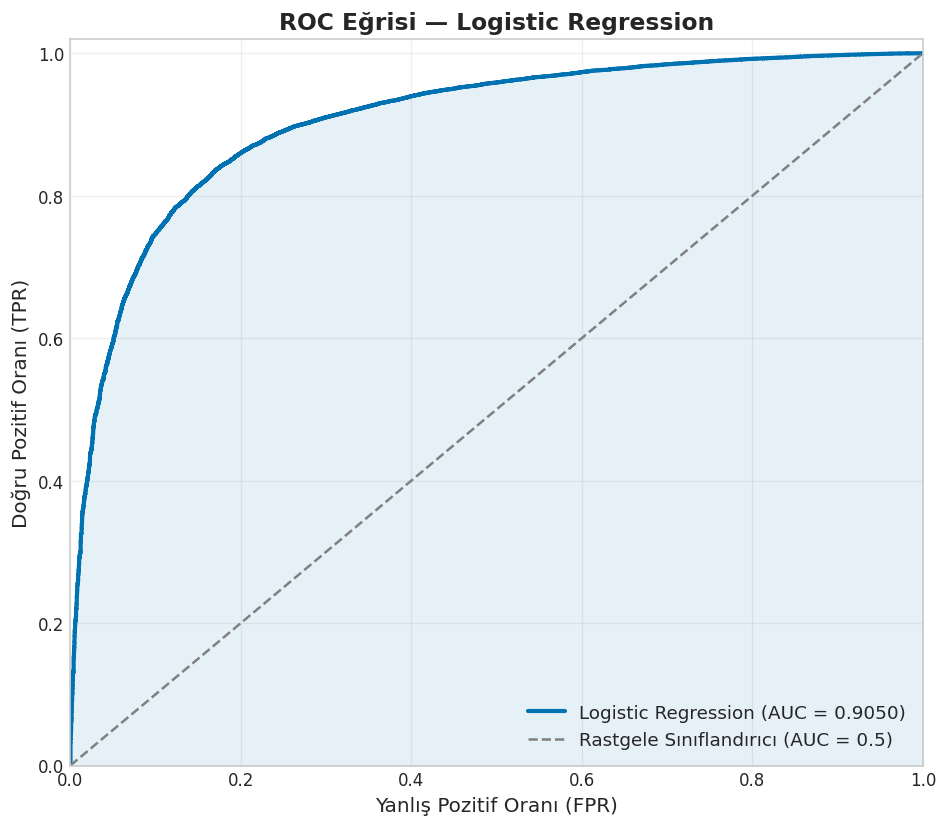

ROC AUC Score: 0.9050


In [13]:
# Probability kolonundan pozitif sınıf olasılıklarını çıkar
roc_data = best_predictions.select(
    F.col("label"),
    vector_to_array(F.col("probability"))[1].alias("prob_positive")
).toPandas()

fpr, tpr, thresholds = roc_curve(roc_data["label"], roc_data["prob_positive"])
roc_auc = sklearn_auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7))

# ROC eğrisi
ax.plot(fpr, tpr, color=CB_COLORS[0], linewidth=2.5,
        label=f"{best_model_name} (AUC = {roc_auc:.4f})")

# Diagonal baseline (random)
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.5,
        label="Rastgele Sınıflandırıcı (AUC = 0.5)")

# AUC alanını doldur
ax.fill_between(fpr, tpr, alpha=0.1, color=CB_COLORS[0])

ax.set_xlabel("Yanlış Pozitif Oranı (FPR)", fontsize=12)
ax.set_ylabel("Doğru Pozitif Oranı (TPR)", fontsize=12)
ax.set_title(f"ROC Eğrisi — {best_model_name}", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11, framealpha=0.9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"ROC AUC Score: {roc_auc:.4f}")

---
## GÖRSEL 8 — Top 20 Oyun Yorum Analizi (Stacked Horizontal Bar Chart)

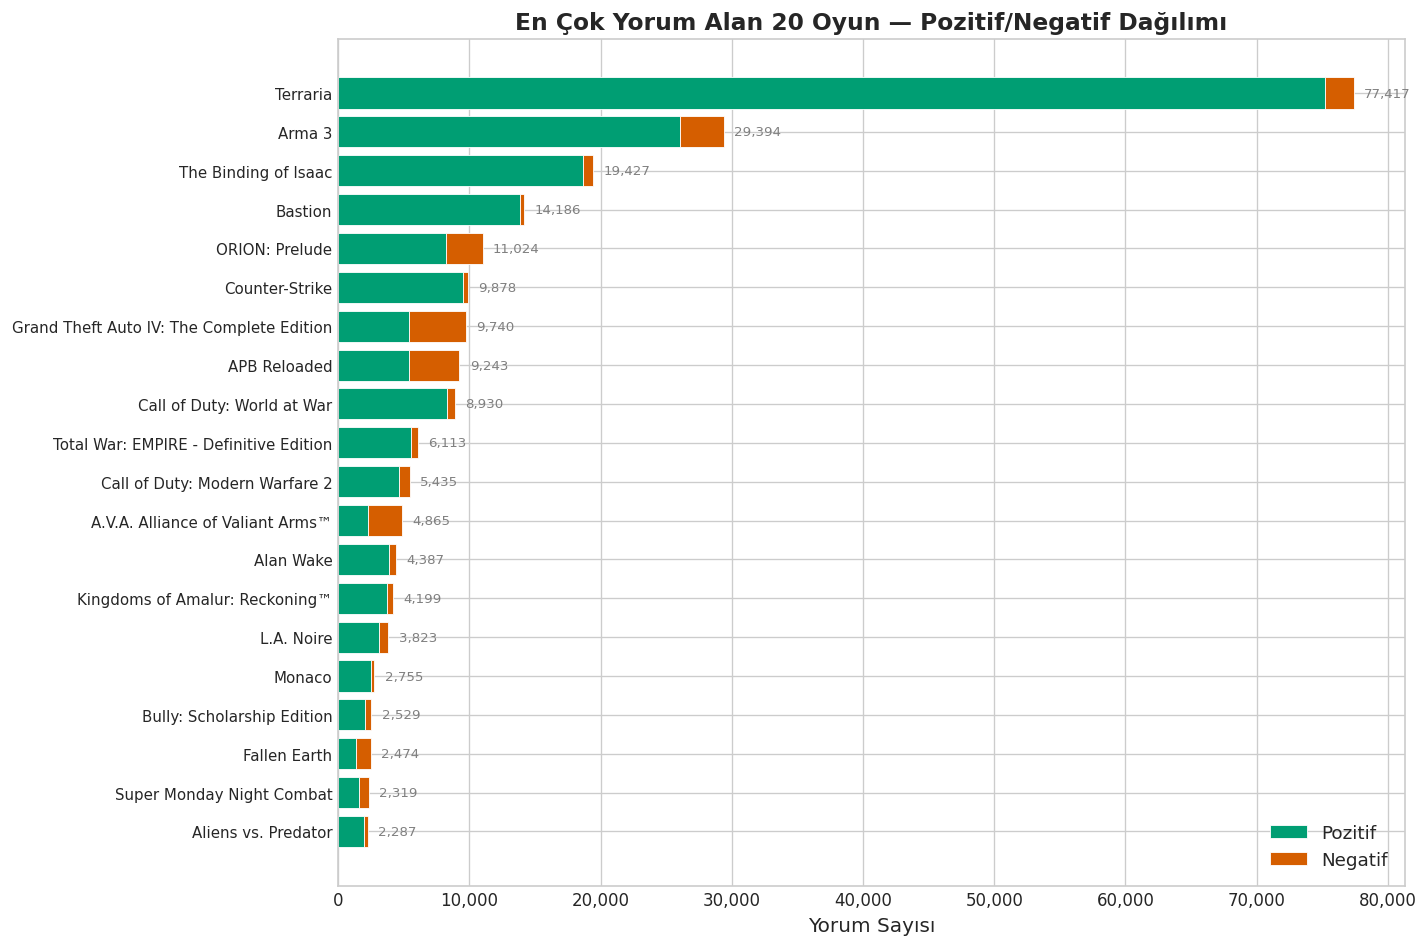

In [14]:
# Oyun bazında pozitif/negatif sayıları
game_stats = pdf_silver.groupby("app_name").agg(
    total=pd.NamedAgg(column="label", aggfunc="count"),
    positive=pd.NamedAgg(column="label", aggfunc="sum")
).reset_index()
game_stats["negative"] = game_stats["total"] - game_stats["positive"]
game_stats = game_stats.sort_values("total", ascending=False).head(20).reset_index(drop=True)

# Ters sıralama (en çok yorumlanan en üstte)
game_stats_plot = game_stats.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(game_stats_plot))

# Stacked bar: pozitif + negatif
bars_pos = ax.barh(y_pos, game_stats_plot["positive"],
                   color=CB_COLORS[2], edgecolor="white", linewidth=0.5,
                   label="Pozitif")
bars_neg = ax.barh(y_pos, game_stats_plot["negative"],
                   left=game_stats_plot["positive"],
                   color=CB_COLORS[4], edgecolor="white", linewidth=0.5,
                   label="Negatif")

ax.set_yticks(y_pos)
ax.set_yticklabels(game_stats_plot["app_name"], fontsize=9)
ax.set_xlabel("Yorum Sayısı")
ax.set_title("En Çok Yorum Alan 20 Oyun — Pozitif/Negatif Dağılımı",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11, framealpha=0.9)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Bar sonuna toplam değer yaz
for idx, row in game_stats_plot.iterrows():
    ax.text(row["total"] + game_stats_plot["total"].max() * 0.01, idx,
            f"{row['total']:,}", va="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

---
## SON BÖLÜM — Dashboard Özet Sayfası (2x4 Grid)

Dashboard kaydedildi: dashboard_final.png (dpi=200)


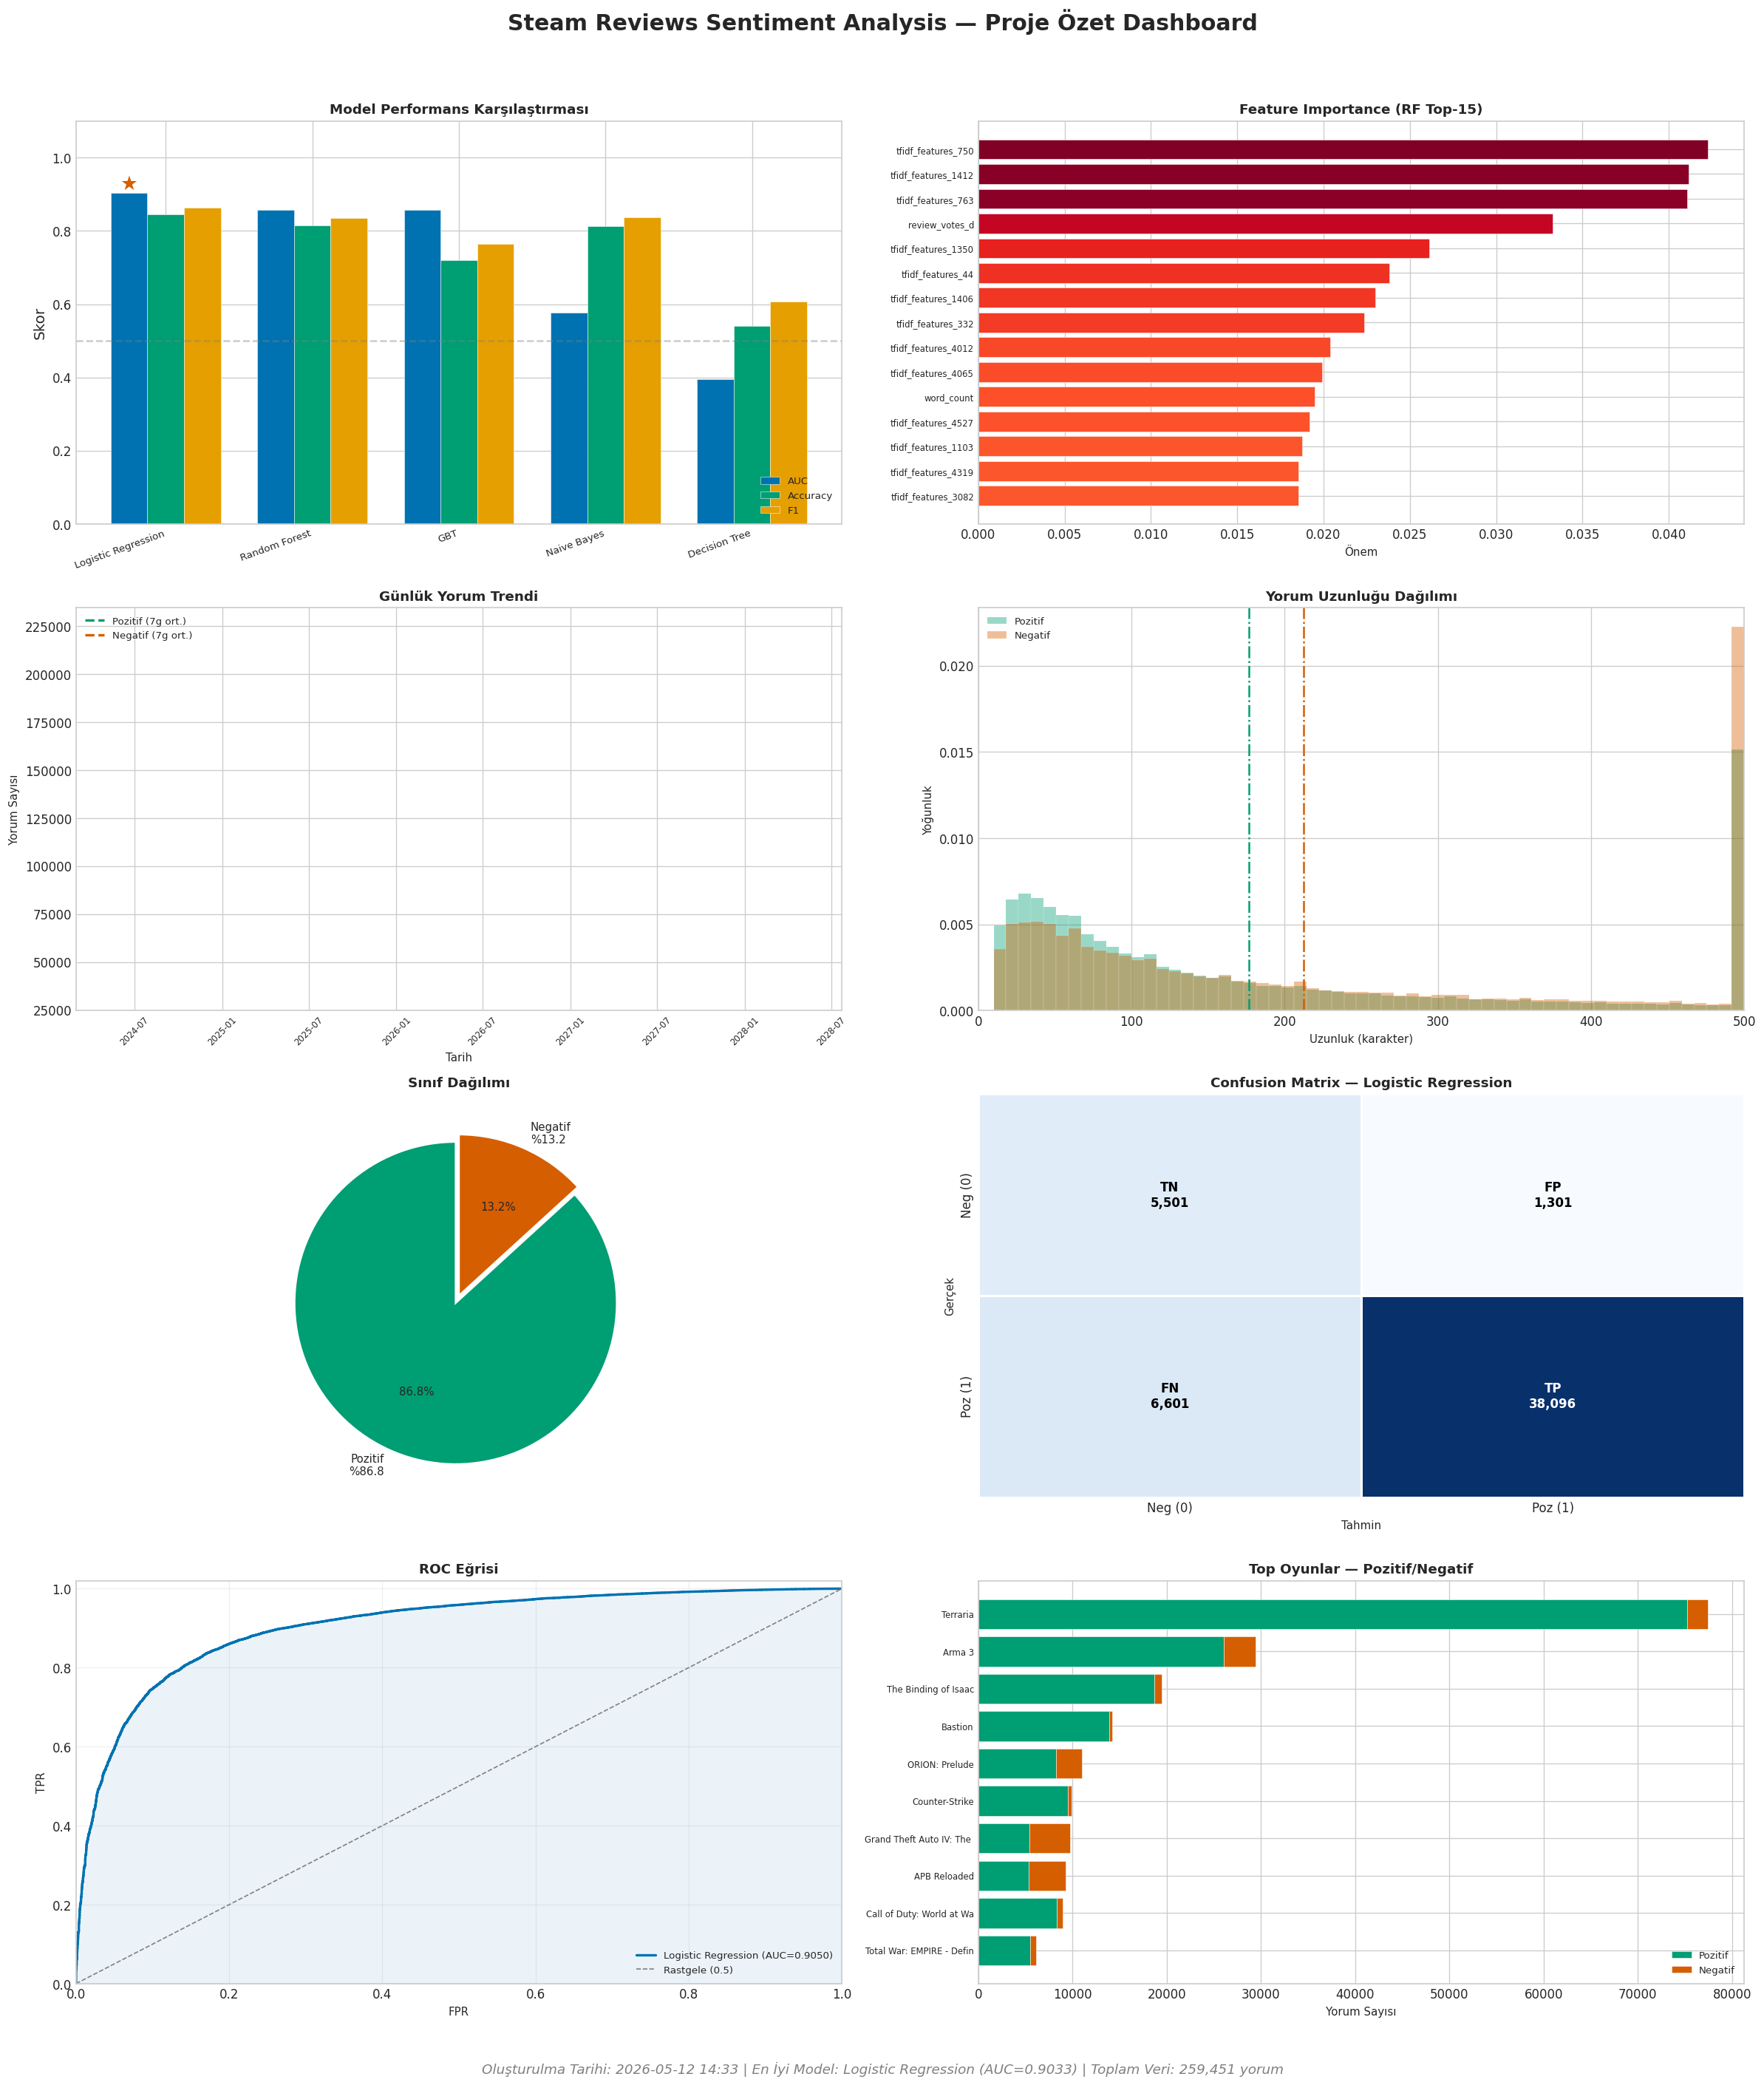

In [15]:
fig = plt.figure(figsize=(20, 24))
fig.suptitle("Steam Reviews Sentiment Analysis — Proje Özet Dashboard",
             fontsize=18, fontweight="bold", y=0.98)

# ═══════════════════════════════════════════════════════════════════
# GÖRSEL 1 — Model AUC Karşılaştırması (1. satır, 1. kolon)
# ═══════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(4, 2, 1)
metrics_to_plot = ["AUC", "Accuracy", "F1"]
x = np.arange(len(model_results))
width = 0.25
colors_g1 = [CB_COLORS[0], CB_COLORS[2], CB_COLORS[1]]
for i, metric in enumerate(metrics_to_plot):
    ax1.bar(x + i * width, model_results[metric], width,
            label=metric, color=colors_g1[i], edgecolor="white", linewidth=0.3)
best_idx = model_results["AUC"].idxmax()
ax1.annotate("★", xy=(best_idx, model_results.loc[best_idx, "AUC"] + 0.01),
             fontsize=16, ha="center", color="#D55E00")
ax1.set_xticks(x + width)
ax1.set_xticklabels(model_results["Model"], rotation=20, ha="right", fontsize=8)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel("Skor")
ax1.set_title("Model Performans Karşılaştırması", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8, loc="lower right")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)

# ═══════════════════════════════════════════════════════════════════
# GÖRSEL 2 — Feature Importance (1. satır, 2. kolon)
# ═══════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(4, 2, 2)
top_n_dash = 15
indices_dash = np.argsort(importances)[::-1][:top_n_dash]
top_imp_dash = importances[indices_dash]
top_lbl_dash = [f"F_{idx}" for idx in indices_dash]
try:
    top_lbl_dash = [attr_dict.get(idx, f"F_{idx}")[:20] for idx in indices_dash]
except:
    pass
norm_d = top_imp_dash / top_imp_dash.max()
colors_d = plt.cm.YlOrRd(norm_d[::-1] * 0.7 + 0.3)
ax2.barh(range(top_n_dash), top_imp_dash[::-1], color=colors_d, edgecolor="white", linewidth=0.3)
ax2.set_yticks(range(top_n_dash))
ax2.set_yticklabels(top_lbl_dash[::-1], fontsize=7)
ax2.set_xlabel("Önem", fontsize=9)
ax2.set_title("Feature Importance (RF Top-15)", fontsize=11, fontweight="bold")

# ═══════════════════════════════════════════════════════════════════
# GÖRSEL 3 — Günlük Yorum Trendi (2. satır, 1. kolon)
# ═══════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(4, 2, 3)
ax3.plot(daily_agg["review_date"], daily_agg["positive"],
         color=CB_COLORS[2], alpha=0.3, linewidth=0.6)
ax3.plot(daily_agg["review_date"], daily_agg["negative"],
         color=CB_COLORS[4], alpha=0.3, linewidth=0.6)
ax3.plot(daily_agg["review_date"], daily_agg["positive_ma7"],
         color=CB_COLORS[2], linewidth=2, linestyle="--", label="Pozitif (7g ort.)")
ax3.plot(daily_agg["review_date"], daily_agg["negative_ma7"],
         color=CB_COLORS[4], linewidth=2, linestyle="--", label="Negatif (7g ort.)")
ax3.set_xlabel("Tarih", fontsize=9)
ax3.set_ylabel("Yorum Sayısı", fontsize=9)
ax3.set_title("Günlük Yorum Trendi", fontsize=11, fontweight="bold")
ax3.legend(fontsize=8, loc="upper left")
ax3.tick_params(axis="x", rotation=45, labelsize=7)

# ═══════════════════════════════════════════════════════════════════
# GÖRSEL 4 — Yorum Uzunluğu Dağılımı (2. satır, 2. kolon)
# ═══════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(4, 2, 4)
ax4.hist(pos_lengths_clipped, bins=60, color=CB_COLORS[2], alpha=0.4,
         density=True, edgecolor="white", linewidth=0.2, label="Pozitif")
ax4.hist(neg_lengths_clipped, bins=60, color=CB_COLORS[4], alpha=0.4,
         density=True, edgecolor="white", linewidth=0.2, label="Negatif")
ax4.axvline(pos_mean, color=CB_COLORS[2], linestyle="-.", linewidth=1.5)
ax4.axvline(neg_mean, color=CB_COLORS[4], linestyle="-.", linewidth=1.5)
ax4.set_xlabel("Uzunluk (karakter)", fontsize=9)
ax4.set_ylabel("Yoğunluk", fontsize=9)
ax4.set_title("Yorum Uzunluğu Dağılımı", fontsize=11, fontweight="bold")
ax4.legend(fontsize=8)
ax4.set_xlim(0, p99)

# ═══════════════════════════════════════════════════════════════════
# GÖRSEL 5 — Sınıf Dağılımı Pie (3. satır, 1. kolon)
# ═══════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(4, 2, 5)
sizes = [pos_count, neg_count]
labels_pie = [f"Pozitif\n%{pos_count/total*100:.1f}", f"Negatif\n%{neg_count/total*100:.1f}"]
colors_p = [CB_COLORS[2], CB_COLORS[4]]
ax5.pie(sizes, explode=(0.05, 0), labels=labels_pie, colors=colors_p,
        autopct="%1.1f%%", startangle=90, textprops={"fontsize": 9},
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax5.set_title("Sınıf Dağılımı", fontsize=11, fontweight="bold")

# ═══════════════════════════════════════════════════════════════════
# GÖRSEL 6 — Confusion Matrix (3. satır, 2. kolon)
# ═══════════════════════════════════════════════════════════════════
ax6 = fig.add_subplot(4, 2, 6)
sns.heatmap(cm, annot=False, cmap="Blues", ax=ax6,
            xticklabels=["Neg (0)", "Poz (1)"],
            yticklabels=["Neg (0)", "Poz (1)"],
            linewidths=1.5, linecolor="white", cbar=False)
annot_labels = [[f"TN\n{tn:,}", f"FP\n{fp:,}"], [f"FN\n{fn:,}", f"TP\n{tp:,}"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        color = "white" if val > cm.max() / 2 else "black"
        ax6.text(j + 0.5, i + 0.5, annot_labels[i][j],
                 ha="center", va="center", fontsize=10, fontweight="bold", color=color)
ax6.set_xlabel("Tahmin", fontsize=9)
ax6.set_ylabel("Gerçek", fontsize=9)
ax6.set_title(f"Confusion Matrix — {best_model_name}", fontsize=11, fontweight="bold")

# ═══════════════════════════════════════════════════════════════════
# GÖRSEL 7 — ROC Curve (4. satır, 1. kolon)
# ═══════════════════════════════════════════════════════════════════
ax7 = fig.add_subplot(4, 2, 7)
ax7.plot(fpr, tpr, color=CB_COLORS[0], linewidth=2,
         label=f"{best_model_name} (AUC={roc_auc:.4f})")
ax7.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Rastgele (0.5)")
ax7.fill_between(fpr, tpr, alpha=0.08, color=CB_COLORS[0])
ax7.set_xlabel("FPR", fontsize=9)
ax7.set_ylabel("TPR", fontsize=9)
ax7.set_title("ROC Eğrisi", fontsize=11, fontweight="bold")
ax7.legend(fontsize=8, loc="lower right")
ax7.set_xlim([0, 1])
ax7.set_ylim([0, 1.02])
ax7.grid(True, alpha=0.3)

# ═══════════════════════════════════════════════════════════════════
# GÖRSEL 8 — Top 20 Oyun (4. satır, 2. kolon)
# ═══════════════════════════════════════════════════════════════════
ax8 = fig.add_subplot(4, 2, 8)
top10_plot = game_stats.head(10).iloc[::-1].reset_index(drop=True)
y8 = np.arange(len(top10_plot))
ax8.barh(y8, top10_plot["positive"], color=CB_COLORS[2],
         edgecolor="white", linewidth=0.3, label="Pozitif")
ax8.barh(y8, top10_plot["negative"], left=top10_plot["positive"],
         color=CB_COLORS[4], edgecolor="white", linewidth=0.3, label="Negatif")
ax8.set_yticks(y8)
ax8.set_yticklabels(top10_plot["app_name"].str[:25], fontsize=7)
ax8.set_xlabel("Yorum Sayısı", fontsize=9)
ax8.set_title("Top Oyunlar — Pozitif/Negatif", fontsize=11, fontweight="bold")
ax8.legend(fontsize=8, loc="lower right")

# ═══════════════════════════════════════════════════════════════════
# Alt bilgi
# ═══════════════════════════════════════════════════════════════════
fig.text(0.5, 0.01,
         f"Oluşturulma Tarihi: {datetime.now().strftime('%Y-%m-%d %H:%M')} | "
         f"En İyi Model: {best_model_name} (AUC={best_auc:.4f}) | "
         f"Toplam Veri: {total:,} yorum",
         ha="center", fontsize=11, color="gray", style="italic")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# Dosya olarak kaydet
fig.savefig("dashboard_final.png", dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
print("Dashboard kaydedildi: dashboard_final.png (dpi=200)")

plt.show()

In [16]:
# ── Özet ─────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("DASHBOARD ÖZET")
print("="*70)
print(f"  Toplam Yorum Sayısı     : {total:,}")
print(f"  Pozitif / Negatif       : {pos_count:,} / {neg_count:,}")
print(f"  Benzersiz Oyun          : {pdf_silver['app_name'].nunique():,}")
print(f"  Eğitilen Model Sayısı   : {len(model_results)}")
print(f"  En İyi Model            : {best_model_name}")
print(f"  En İyi AUC              : {best_auc:.4f}")
print(f"  Dashboard Dosyası       : dashboard_final.png")
print("="*70)
print("\nDashboard oluşturma tamamlandı ✓")


DASHBOARD ÖZET
  Toplam Yorum Sayısı     : 259,451
  Pozitif / Negatif       : 225,154 / 34,297
  Benzersiz Oyun          : 118
  Eğitilen Model Sayısı   : 5
  En İyi Model            : Logistic Regression
  En İyi AUC              : 0.9033
  Dashboard Dosyası       : dashboard_final.png

Dashboard oluşturma tamamlandı ✓


In [17]:
# ── Spark oturumunu kapat ────────────────────────────────────────────────────
spark.stop()
print("Spark oturumu kapatıldı ✓")

Spark oturumu kapatıldı ✓
